# Tutorial 00 (Lung, Demo): Predict Lung Motion From a Single Chest CT

## Purpose

A self-contained demo of the lung motion-prediction pipeline that fetches
every input it needs, so it runs with nothing more than a clone of the
repository:

1. Download the ``Chest-CT`` sample volume (an ungated 3-D chest CT) and the
   pretrained ``physicsnemo_mgn_lung_motion`` MeshGraphNet checkpoint with
   ``monai_physio.DownloadData``. The checkpoint directory also carries the
   lung PCA shape model (``pca_model.json``, ``pca_mean_surface.vtp``) that
   network was trained against, so no separate Tutorial 6 run is needed.
2. Segment the lungs with ``SegmentChestTotalSegmentator`` and extract their
   surface.
3. Fit that PCA shape model to the surface with
   ``WorkflowFitStatisticalModelToPatient``, giving this patient's PCA
   coefficients and fitted SSM surface.
4. Predict lung motion across a demo respiratory-stage grid with the
   pretrained MeshGraphNet, carry the CT through each stage's deformation,
   and write the series as VTP surfaces and one animated USD --
   ``WorkflowInferMovement.process_time_series``.

``Chest-CT`` is a single, ungated volume -- unlike ``TCIA-4DLung``'s gated
sequences, it has no ``g{PPP}`` respiratory phases to parse a stage grid
from. This demo instead predicts motion across an illustrative grid of
normalized stages, so the same pretrained network that predicts a real
respiratory cycle in ``tutorial_12_lung_end_to_end_inference.py`` can be
shown working on any chest CT.

## Data Required

Nothing -- the ``Chest-CT`` volume, the pretrained MeshGraphNet weights and
the PCA shape model they were trained against are all downloaded by this
notebook.

## Outputs (under ``output/tutorial_00_lung_demo/``)

  * ``Chest-CT_lung_surface.vtp``, ``Chest-CT_lung_labelmap.nii.gz`` -- segmentation
  * ``Chest-CT_surface.json`` -- this patient's shape parameters
  * ``Chest-CT_ssm_surface.vtp`` -- the model fitted to the patient
  * ``Chest-CT_surface_s{TTT}_pred.vtp`` -- predicted surface per stage
  * ``Chest-CT_s{TTT}_pred.mha`` -- CT carried to that stage
  * ``Chest-CT_pred.usd`` -- animated predicted motion

In [1]:
# Imports
import json
import logging
from typing import cast

import itk
import numpy as np
import pyvista as pv
from parameters_tcia_4d_lung import TCIA_4D_LUNG

from monai_physio import (
    DownloadData,
    ProcessContours,
    SegmentChestTotalSegmentator,
    WorkflowConvertImageToVTK,
    WorkflowFitStatisticalModelToPatient,
    WorkflowInferMovement,
    WorkflowInferPhysicsNeMo,
)

In [2]:
# Data directory specification
test_mode = False

case_id = "Chest-CT"

data_dir = TCIA_4D_LUNG.hold_out_directory(test_mode)
weights_dir = TCIA_4D_LUNG.weights_directory(test_mode)
output_dir = TCIA_4D_LUNG.output_directory(test_mode) / "tutorial_00_lung_demo"

# Weights Tutorial 9 trains; this demo downloads a pretrained copy instead.
# The PCA model and mean surface it was trained against ship in the same
# checkpoint directory.
model_dir = TCIA_4D_LUNG.mgn_weights_directory(test_mode)
epoch = None  # None uses the final weights
pca_model_file = model_dir / "pca_model.json"
pca_mean_file = model_dir / "pca_mean_surface.vtp"

number_of_pca_components = TCIA_4D_LUNG.pca_components(test_mode)

# time points to reconstruct
stages = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Gaussian sigma, in mm, that spreads the predicted surface displacements
# into the continuous field the CT is resampled through.
smoothing_sigma_mm = 10.0

log_level = logging.INFO
logging.basicConfig(level=log_level)
logger = logging.getLogger("tutorial_00_lung_demo")

output_dir.mkdir(parents=True, exist_ok=True)

## Step 1: Download the Chest-CT volume and the pretrained MeshGraphNet weights

In [3]:
patient_image_file = DownloadData.DownloadChestCTData(data_dir)
DownloadData.DownloadPhysicsNeMoMGNLungMotionData(weights_dir)

if not (model_dir / "mgn_stage_model.pt").exists():
    raise FileNotFoundError(
        f"Pretrained MeshGraphNet checkpoint not found: {model_dir}"
    )
if not (pca_model_file.exists() and pca_mean_file.exists()):
    raise FileNotFoundError(
        f"PCA shape model not found alongside checkpoint: {model_dir}"
    )

pca_mean_surface = cast(pv.DataSet, pv.read(str(pca_mean_file)))
with pca_model_file.open(encoding="utf-8") as f:
    pca_model = json.load(f)

patient_image = itk.imread(str(patient_image_file))
logger.info("Loaded %s", patient_image_file)

INFO:tutorial_00_lung_demo:Loaded C:\src\Projects\MONAI-Physio\monai-physio\data\Chest-CT\Chest-CT.mha


## Step 2: Segment the lungs with TotalSegmentator

In [4]:
lung_surface_file = output_dir / f"{case_id}_lung_surface.vtp"
lung_labelmap_file = output_dir / f"{case_id}_lung_labelmap.nii.gz"

contour_tools = ProcessContours(log_level=log_level)
segmentation_method = SegmentChestTotalSegmentator(log_level=log_level)
segmentation_method.fast_mode = True
segmentation_result = WorkflowConvertImageToVTK(
    segmentation_method=segmentation_method,
    log_level=log_level,
).process(
    input_image=patient_image,
    anatomy_groups=[TCIA_4D_LUNG.anatomy_group],
    surface_reduction_rate=TCIA_4D_LUNG.surface_reduction_rate,
    extract_label_surfaces=True,
)
contour_tools.save_combined_surfaces(
    segmentation_result["label_surfaces"], str(lung_surface_file)
)
# anatomy_groups only selects which structures are contoured into
# label_surfaces above; the labelmap itself is the segmenter's full,
# unfiltered whole-body output (ribs, spine, heart, etc. included).
lung_labelmap = segmentation_result["labelmap"]
itk.imwrite(lung_labelmap, str(lung_labelmap_file), compression=True)
# Read back rather than combining in memory: save_combined_surfaces is what
# merges the per-label surfaces into the one surface the fit is given.
lung_surface = cast(pv.PolyData, pv.read(str(lung_surface_file)))
logger.info("Segmented lungs in %s", patient_image_file.name)

# Isolate just the lung labels into a binary mask, the same way
# tutorial_13_heart_and_lung_motion.py's binary_mask_on_grid does: this (not
# the whole-body lung_labelmap above) is what exterior_mask must be, or
# nearly every voxel in the torso reads as "interior" and gets the full,
# unrestricted deformation instead of only the lung's push and pull.
lung_label_ids = list(segmentation_method.taxonomy.labels_in_group("lung"))
lung_only_mask_arr = np.isin(
    itk.array_from_image(lung_labelmap), lung_label_ids
).astype(np.uint8)
lung_only_mask = itk.image_from_array(lung_only_mask_arr)
lung_only_mask.CopyInformation(lung_labelmap)

2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK ======================================================================
2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK STARTING IMAGE TO VTK WORKFLOW
2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK ======================================================================
2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK Running segmenter: SegmentChestTotalSegmentator
2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK ======================================================================
2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK Running segmentation
2026-09-20 14:06:13 INFO WorkflowConvertImageToVTK ======================================================================
2026-09-20 14:06:13 WARNING SegmentChestTotalSegmentator The input image should have isotropic spacing
2026-09-20 14:06:13 INFO SegmentChestTotalSegmentator Input image has spacing: itkVectorD3 ([0.814453, 0.814453, 2])
2026-09-20 14:06:13 INFO SegmentChestTo


If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Resampling...
  Resampled in 1.52s
Predicting...


`torch.jit.interface` is deprecated. Please use `torch.compile` instead.
100%|██████████| 4/4 [00:00<00:00,  4.68it/s]


  Predicted in 11.09s
Resampling...
  Resampled in 2.14s


2026-09-20 14:06:36 INFO WorkflowConvertImageToVTK ======================================================================
2026-09-20 14:06:36 INFO WorkflowConvertImageToVTK Extracting VTK objects
2026-09-20 14:06:36 INFO WorkflowConvertImageToVTK ======================================================================
2026-09-20 14:06:36 INFO WorkflowConvertImageToVTK Processing anatomy group: lung
2026-09-20 14:06:36 INFO WorkflowConvertImageToVTK   Extracting surface for: lung
2026-09-20 14:06:36 INFO ProcessContours Contouring on a 0.814 mm isotropic grid rather than the labelmap's 0.814 x 0.814 x 2 mm one
2026-09-20 14:06:50 INFO WorkflowConvertImageToVTK   Extracting label surfaces for: lung
2026-09-20 14:06:50 INFO ProcessContours Contouring on a 0.814 mm isotropic grid rather than the labelmap's 0.814 x 0.814 x 2 mm one
2026-09-20 14:07:02 INFO ProcessContours Contouring on a 0.814 mm isotropic grid rather than the labelmap's 0.814 x 0.814 x 2 mm one
2026-09-20 14:07:14 INFO Proce

## Step 3: Fit the lung shape model to the patient

The PCA coefficients are what the network is conditioned on; the fitted
surface is what its displacements are added to.

In [5]:
fit_workflow = WorkflowFitStatisticalModelToPatient(
    template_model=pca_mean_surface,
    patient_models=[lung_surface],
    patient_image=patient_image,
    patient_labelmap=lung_labelmap,
    log_level=log_level,
)
fit_workflow.set_use_pca_registration(
    use_pca_registration=True,
    pca_model=pca_model,
    number_of_pca_components=number_of_pca_components,
    use_surface=False,
)
fit_workflow.set_icp_transform_type(TCIA_4D_LUNG.icp_transform_type)
fit_workflow.set_mask_dilation_mm(TCIA_4D_LUNG.mask_dilation_mm)
fit_workflow.set_distancemap_squared_max(TCIA_4D_LUNG.distancemap_squared_max)
fit_result = fit_workflow.process()

pca_coefficients = fit_workflow.pca_coefficients
assert pca_coefficients is not None
# WorkflowInferMovement.process_time_series names every predicted surface
# after this file's stem, so naming it "{case_id}_surface" is what gives the
# predicted surfaces their "{case_id}_surface_s{TTT}_pred.vtp" names below.
pca_coefficients_file = output_dir / f"{case_id}_surface.json"
with pca_coefficients_file.open(mode="w", encoding="utf-8") as f:
    json.dump(pca_coefficients.tolist(), f)

# The lung PCA model is built from surfaces only, so the model *is* a
# surface here: only the .vtp is written.
fitted_reference_mesh_file = output_dir / f"{case_id}_ssm_surface.vtp"
fit_result["fitted_reference_mesh"].save(str(fitted_reference_mesh_file))
logger.info("Fitted the lung model to %s", patient_image_file.name)

2026-09-20 14:07:50 INFO WorkflowFitStatisticalModelToPatient ======================================================================
2026-09-20 14:07:50 INFO WorkflowFitStatisticalModelToPatient STARTING COMPLETE MODEL REGISTRATION WORKFLOW
2026-09-20 14:07:50 INFO WorkflowFitStatisticalModelToPatient ======================================================================
2026-09-20 14:07:50 INFO WorkflowFitStatisticalModelToPatient ======================================================================
2026-09-20 14:07:50 INFO WorkflowFitStatisticalModelToPatient Stage 1: ICP Alignment (RegisterModelsICP)
2026-09-20 14:07:50 INFO WorkflowFitStatisticalModelToPatient ======================================================================
2026-09-20 14:07:50 INFO RegisterModelsICP ======================================================================
2026-09-20 14:07:50 INFO RegisterModelsICP AFFINE ICP Alignment
2026-09-20 14:07:50 INFO RegisterModelsICP ==================================

Initial optimizer parameters -0.382393 119.257 -0.0819714 -0.232237 0.0774079 0.134809 119.234 -0.162708 0.280448 -0.0612102 0.328657 100.923
Initial optimizer parameters 3.21966 238.522 1.60357 6.12603 0.225662 -4.27735 234.453 0.47884 -1.43414 -11.1174 3.00694 196.594
Initial optimizer parameters 2.5075 475.011 2.90369 9.54114 0.518151 -8.1374 469.417 1.76692 -1.60669 -18.2456 7.30883 392.883


2026-09-20 14:11:29 INFO RegisterImagesGreedy Greedy affine/rigid registration loss: -6020.821464534253
2026-09-20 14:11:29 INFO RegisterModelsDistanceMaps Performing ICON deformable registration...


ICONLoss(all_loss=tensor(0.1363, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0244, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.0996, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0001, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'))
ICONLoss(all_loss=tensor(0.1136, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0103, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.0981, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(2.9999e-05, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'))
ICONLoss(all_loss=tensor(0.1093, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0076, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.0979, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(2.0893e-05, device='cuda:0', grad_fn=<MeanBackward0>)

2026-09-20 14:12:03 INFO RegisterModelsDistanceMaps Transforming moving model...
2026-09-20 14:12:05 INFO RegisterModelsDistanceMaps DEFORMABLE distance-map-based registration complete.
2026-09-20 14:12:05 INFO WorkflowFitStatisticalModelToPatient Stage 3 complete: Labelmap-to-labelmap registration finished.
2026-09-20 14:12:05 INFO WorkflowFitStatisticalModelToPatient Applying transforms to model...
2026-09-20 14:12:05 INFO WorkflowFitStatisticalModelToPatient Applying PCA: 1/3 (33.3%)
2026-09-20 14:12:07 INFO WorkflowFitStatisticalModelToPatient Applying PCA post-transform: 2/3 (66.7%)
2026-09-20 14:12:09 INFO WorkflowFitStatisticalModelToPatient Applying Labelmap-to-labelmap: 3/3 (100.0%)
2026-09-20 14:12:10 INFO WorkflowFitStatisticalModelToPatient Transform application complete.
2026-09-20 14:12:10 INFO WorkflowFitStatisticalModelToPatient ======================================================================
2026-09-20 14:12:10 INFO WorkflowFitStatisticalModelToPatient REGISTRATI

## Step 4: Predict lung motion with the pretrained MeshGraphNet

Predict every demo stage, warp the reference CT through each stage's
deformation, and write the animated USD. -1000 HU is air, the value a CT
grid samples outside itself. `exterior_mask=lung_labelmap` restricts the warp
outside the lungs to the surface-normal component, fading to zero by
`exterior_falloff_distance_mm`, so the chest wall and mediastinum are pushed
and pulled by the breathing lung rather than dragged along with it.

In [ ]:
infer_workflow = WorkflowInferPhysicsNeMo(
    model_directory=model_dir, epoch=epoch, log_level=log_level
)
infer_result = WorkflowInferMovement(
    infer_workflow, log_level=log_level
).process_time_series(
    shape_parameters=pca_coefficients_file,
    stages=stages,
    output_directory=output_dir,
    fitted_reference_mesh=fitted_reference_mesh_file,
    reference_image=patient_image,
    warp_interpolation="linear",
    warp_background_value=-1000.0,
    smoothing_sigma_mm=smoothing_sigma_mm,
    usd_project_name=f"{case_id}_pred",
    anatomy_type="lung",
    separate_by_connectivity=True,
    exterior_mask=lung_only_mask,
    exterior_falloff_distance_mm=10.0,
)

# process_time_series names the warped CT "{stem}_s{TTT}_warped.mha"; rename
# each to this notebook's "{case_id}_s{TTT}_pred.mha" convention.
warped_images = []
for stage, warped_file in zip(stages, infer_result["warped_images"]):
    tag = f"s{int(stage * 100):03d}"
    renamed_file = output_dir / f"{case_id}_{tag}_pred.mha"
    warped_file.replace(renamed_file)
    warped_images.append(renamed_file)
infer_result["warped_images"] = warped_images

logger.info("USD: %s", infer_result["usd_file"])

2026-09-20 14:29:23 INFO WorkflowInferPhysicsNeMo Loading MGN model from C:\src\Projects\MONAI-Physio\monai-physio\tutorials\network_weights\physicsnemo_mgn_lung_motion\mgn_stage_model.pt
2026-09-20 14:29:23 INFO WorkflowInferMovement ======================================================================
2026-09-20 14:29:23 INFO WorkflowInferMovement INFER MOVEMENT TIME SERIES [Chest-CT_surface]
2026-09-20 14:29:23 INFO WorkflowInferMovement ======================================================================
2026-09-20 14:29:27 INFO WorkflowInferMovement Deformation field: 177434/44564480 voxels populated by 282782 vertices
2026-09-20 14:29:45 INFO WorkflowInferMovement stage 0.000 -> Chest-CT_surface_s000_pred.vtp
2026-09-20 14:29:49 INFO WorkflowInferMovement Deformation field: 176256/44564480 voxels populated by 282782 vertices
2026-09-20 14:30:07 INFO WorkflowInferMovement stage 0.100 -> Chest-CT_surface_s010_pred.vtp
2026-09-20 14:30:10 INFO WorkflowInferMovement Deformation fi

## Step 5: Look at the fitted and predicted surfaces

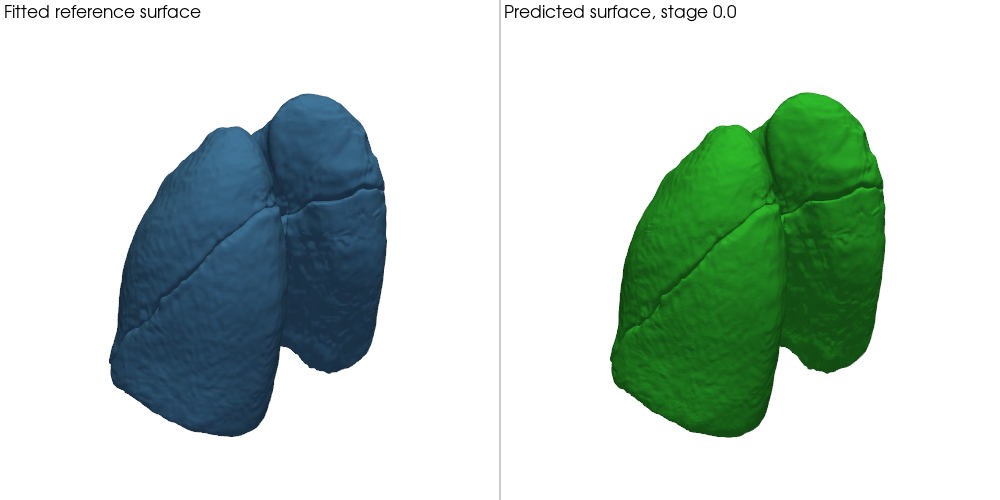

In [7]:
pv.set_jupyter_backend("static")

plotter = pv.Plotter(shape=(1, 2), window_size=[1000, 500])
plotter.subplot(0, 0)
plotter.add_mesh(
    cast(pv.DataSet, pv.read(str(fitted_reference_mesh_file))),
    color="steelblue",
)
plotter.add_text("Fitted reference surface", font_size=10)
plotter.camera_position = "iso"

plotter.subplot(0, 1)
plotter.add_mesh(
    cast(pv.DataSet, pv.read(str(infer_result["predicted_surfaces"][0]))),
    color="limegreen",
)
plotter.add_text(f"Predicted surface, stage {stages[0]}", font_size=10)
plotter.camera_position = "iso"

plotter.show()